In [90]:
#lets make quadratic equation solver workflow 
#because it have conditions 
# eq=ax^2+bx+c 
#here we have to find out its roots 
#for finding its roots it have different conditions
#that's we can solve them by the conditional workflow 


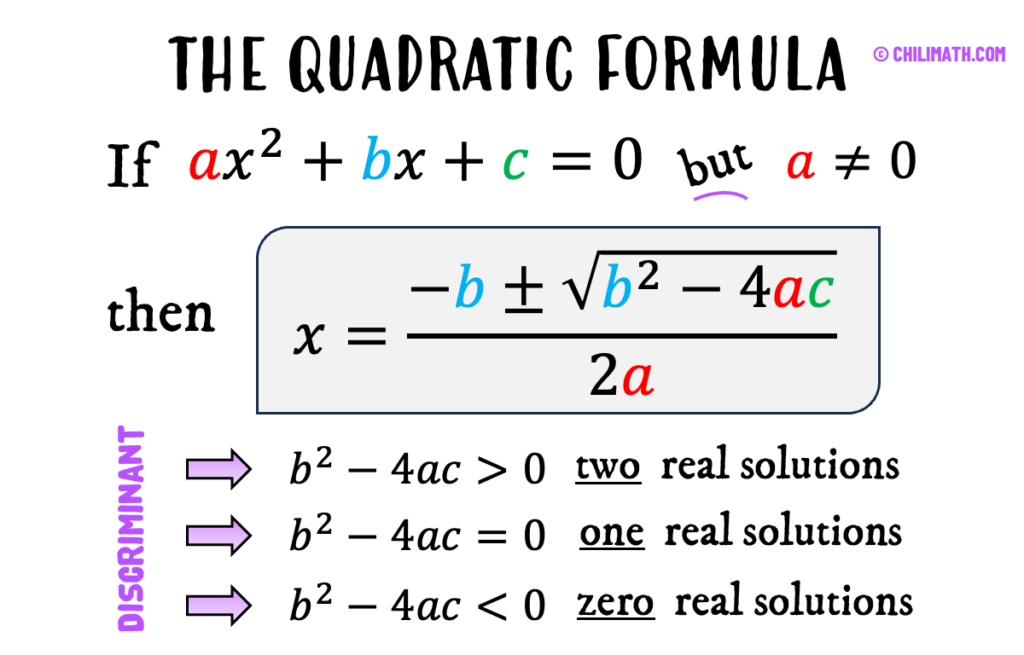

In [91]:
#as you can see the conditions in the above picture 
#lets import all the important libraries
from langgraph.graph import StateGraph,END,START 
 
from typing import TypedDict,Literal 

In [ ]:
#lets make a state for this workflow
class Equation_state(TypedDict):
    a: int 
    b: int 
    c: int 
    equation: str 
    discriminant: float 
    result: str 
    

In [93]:
graph=StateGraph(Equation_state)

In [94]:
#lets create nodes function for our graph 
def Show_equation(state: Equation_state)-> Equation_state:
    #here we have to make the quadratic equation with the help of the given input values 
    equation=f'{state['a']}x**2+{state['b']}x+{state['c']}' 
    #this is not a parallel workflow so here we can pass the whole state 
    
    state['equation']=equation
    # return {'equation':equation} also we can do like this 
    return state 

#lets make function to calculate the disciminanat 
def Calculate_discriminant(state: Equation_state)-> Equation_state:
    #here we have to find out b**2-4ac 
    discriminant=state['b']**2-(4*state['a']*state['c'])
     
    # return {'discriminant':discriminant} #we can also do the partial updates on the state like this 
    
    state['discriminant']=discriminant 
    return state 
    


In [ ]:
#lets add the logic for the conditional node's function 
def Real_roots(state: Equation_state)-> Equation_state:
    # if the discriminant is > 0 then this will execute 
    root_1=(-state['b']+state['discriminant']**1/2)/(2*state['a'])
    root_2=(-state['b']-state['discriminant']**1/2)/(2*state['a'])
    result=f'The roots are {root_1} and {root_2}' 
    return {'result':result}
    

def No_real_roots(state: Equation_state)-> Equation_state:
    # if the discriminant is < 0 then this will execute 
    result=f'Imaginery roots (No real roots)' 
    return {'result':result }

def Repeated_roots(state: Equation_state)-> Equation_state:
    # if the discriminant is = 0 then this will execute 
    root=(-state['b'])/(2*state['a'])
    result=f'Only repeating roots is {root} '
    return {'result':result } 



#for the conditional workflow we have to create a function to check the condition 

#so the following is the routing function 


#NOTE:- WE HAVE TO RETURN THE NODES NAME NOT THE FUNCTION NAME IN THE ROUTER FUNCTION 

# OUR ROUTER FUNCTION
def Check_condition(state: Equation_state)-> Literal["real_roots",'no_real_roots','repeated_roots']:
    #our condition can return any of these funciton
    if state['discriminant']> 0:
        return "real_roots" 
    elif state['discriminant']==0: 
        return 'repeated_roots' 
    else:
        return 'no_real_roots' 


In [96]:
#lets add all the node 
graph.add_node('show_equation',Show_equation)
graph.add_node('calculate_discriminant',Calculate_discriminant)



#lets add conditional nodes 
graph.add_node('real_roots',Real_roots)
graph.add_node('repeated_roots',Repeated_roots)
graph.add_node('no_real_roots',No_real_roots)


#lets add edges in it 

graph.add_edge(START,'show_equation')
graph.add_edge('show_equation','calculate_discriminant')
graph.add_conditional_edges('calculate_discriminant',Check_condition) #this will add edge automatically 
#according to the given condition 
graph.add_edge('real_roots',END)
graph.add_edge('no_real_roots',END)
graph.add_edge('repeated_roots',END) 




In [97]:
#lets compile our graph and make a workflow 
workflow=graph.compile() 


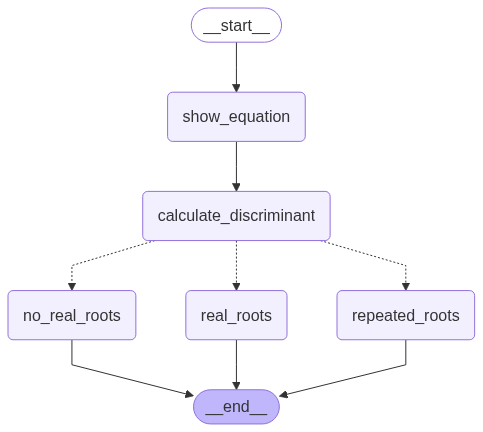

In [98]:
workflow

In [101]:
initial_state={'a':2,'b':4,'c':2}
final_state=workflow.invoke(initial_state)

In [102]:
final_state

{'a': 2,
 'b': 4,
 'c': 2,
 'equation': '2x**2+4x+2',
 'discriminant': 0,
 'result': 'Only repeating roots is -1.0 '}